In [18]:
import random
from pathlib import Path

import numpy as np
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm.notebook import trange

In [19]:
from coronary_analysis.models.segmentation import CoronaryUNet
from coronary_analysis.transforms.transforms import (
    get_train_transforms,
    get_val_transforms,
)
from coronary_analysis.datasets import ArcadeSyntaxBinaryDataset, DCA1Dataset
from coronary_analysis.metrics import BCEDiceCriterion
from coronary_analysis.utils import show_image, plot_lines

In [20]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [21]:
set_seed(42)

In [22]:
def compute_smp_metrics(
    logits: torch.Tensor, masks: torch.Tensor, threshold: float = 0.5
) -> tuple[float, float]:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).long()
    targets = masks.long()

    tp, fp, fn, tn = smp.metrics.get_stats(
        preds,
        targets,
        mode="binary",
    )

    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
    dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")

    return dice.item(), iou.item()

In [23]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        dice, iou = compute_smp_metrics(logits.detach(), masks)

        total_loss += loss.item() * bs
        total_dice += dice * bs
        total_iou += iou * bs
        total_samples += bs

    return (
        total_loss / total_samples,
        total_dice / total_samples,
        total_iou / total_samples,
    )

In [24]:
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device
):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        bs = images.size(0)
        dice, iou = compute_smp_metrics(logits, masks)

        total_loss += loss.item() * bs
        total_dice += dice * bs
        total_iou += iou * bs
        total_samples += bs

    return (
        total_loss / total_samples,
        total_dice / total_samples,
        total_iou / total_samples,
    )

In [25]:
def training_loop(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    num_epochs: int = 20,
    scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,
):
    best_val_loss = float("inf")
    best_model_state = None
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs")
    history = {
        "train_loss": [],
        "train_dice": [],
        "train_iou": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": [],
    }

    for _ in epoch_bar:
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_dice, val_iou = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step(val_dice)

        epoch_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            train_dice=f"{train_dice:.4f}",
            val_loss=f"{val_loss:.4f}",
            val_dice=f"{val_dice:.4f}",
        )

        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["train_iou"].append(train_iou)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return history

In [26]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [27]:
BATCH_SIZE = 4
IMG_SIZE = 250

In [28]:
ARCADE_DIR = "raw_datasets/arcade/arcade/syntax"

train_arcade = ArcadeSyntaxBinaryDataset(
    root=ARCADE_DIR,
    split="train",
    transform=get_train_transforms(IMG_SIZE),
)
val_arcade = ArcadeSyntaxBinaryDataset(
    root=ARCADE_DIR,
    split="val",
    transform=get_val_transforms(IMG_SIZE),
)

train_loader_arcade = DataLoader(
    train_arcade,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader_arcade = DataLoader(
    val_arcade,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

/home/lukasz/Documents/coronary-stenosis-detection/coronary-analysis/src/coronary_analysis/transforms/transforms.py:11: UserWarning: Argument(s) 'shift_limit, scale_limit, rotate_limit' are not valid for transform Affine
  A.Affine(


loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [29]:
LR = 1e-3
WEIGHT_DECAY = 1e-4

model = CoronaryUNet(encoder_name="resnet34").to(device)
criterion = BCEDiceCriterion(bce_weight=0.4, dice_weight=0.6)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

In [30]:
history = training_loop(
    model=model,
    train_loader=train_loader_arcade,
    val_loader=val_loader_arcade,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=2,
    scheduler=scheduler,
)

Epochs:   0%|          | 0/2 [00:00<?, ?it/s]

In [31]:
def get_stems_from_dir(image_dir: str) -> list[str]:
    image_dir = Path(image_dir)
    stems = []
    for img_path in image_dir.glob("*.pgm"):
        if img_path.name.endswith("_gt.pgm"):
            continue
        stem = img_path.stem
        stems.append(stem)
    return stems

In [32]:
IMAGE_DIR = "raw_datasets/DCA1/Database_134_Angiograms"
stems = get_stems_from_dir(IMAGE_DIR)

train_stems, val_stems = train_test_split(stems, test_size=0.25, random_state=42)

train_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    stems=train_stems,
    transform=get_train_transforms(IMG_SIZE),
)
val_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    stems=val_stems,
    transform=get_val_transforms(IMG_SIZE),
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [33]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

In [34]:
history = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=2,
    scheduler=scheduler,
)

Epochs:   0%|          | 0/2 [00:00<?, ?it/s]

In [35]:
# TODO: threshold tuning

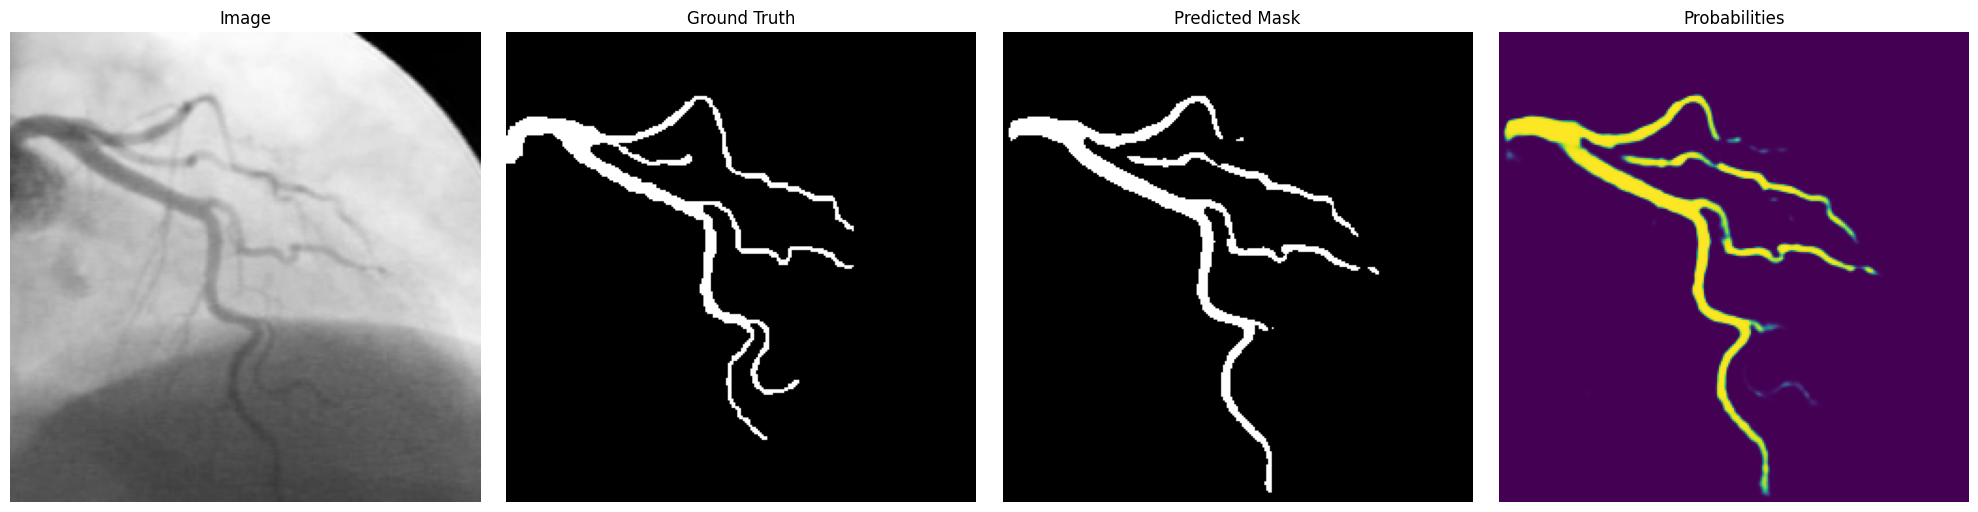

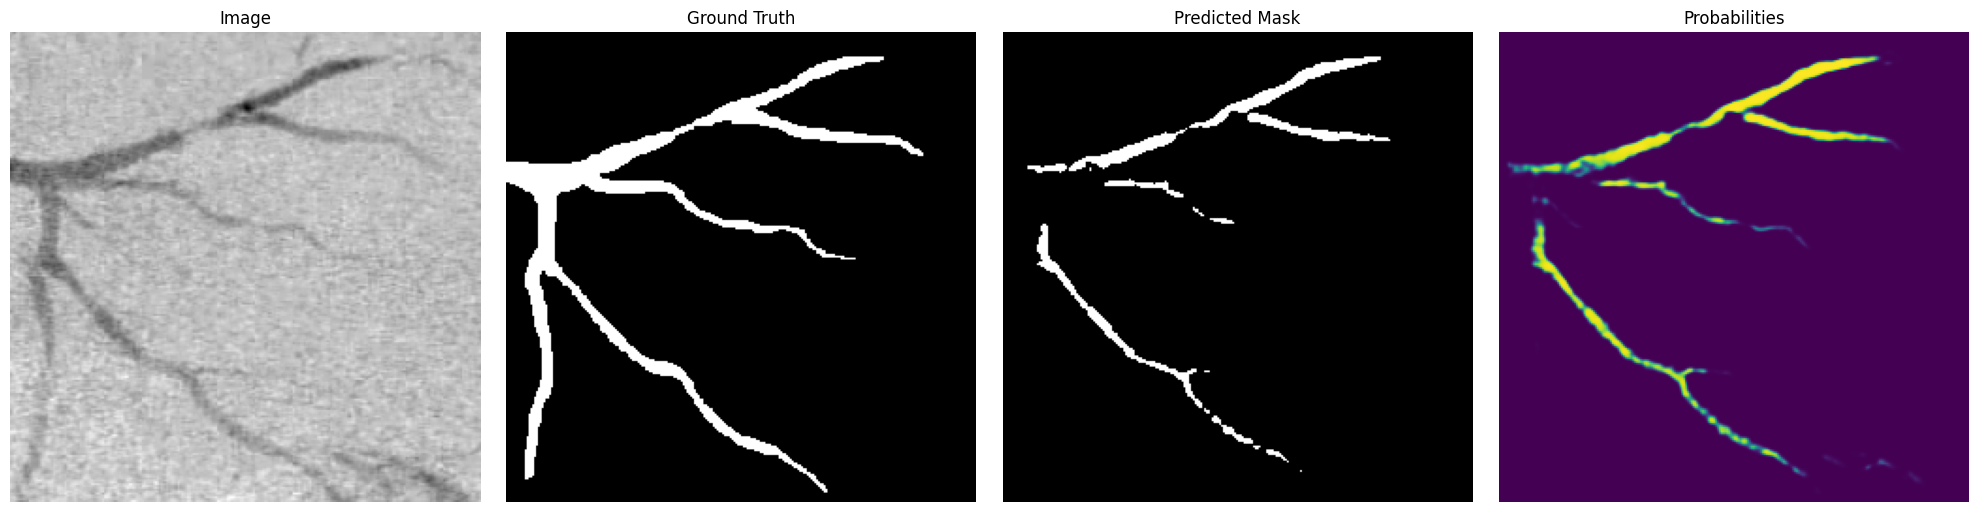

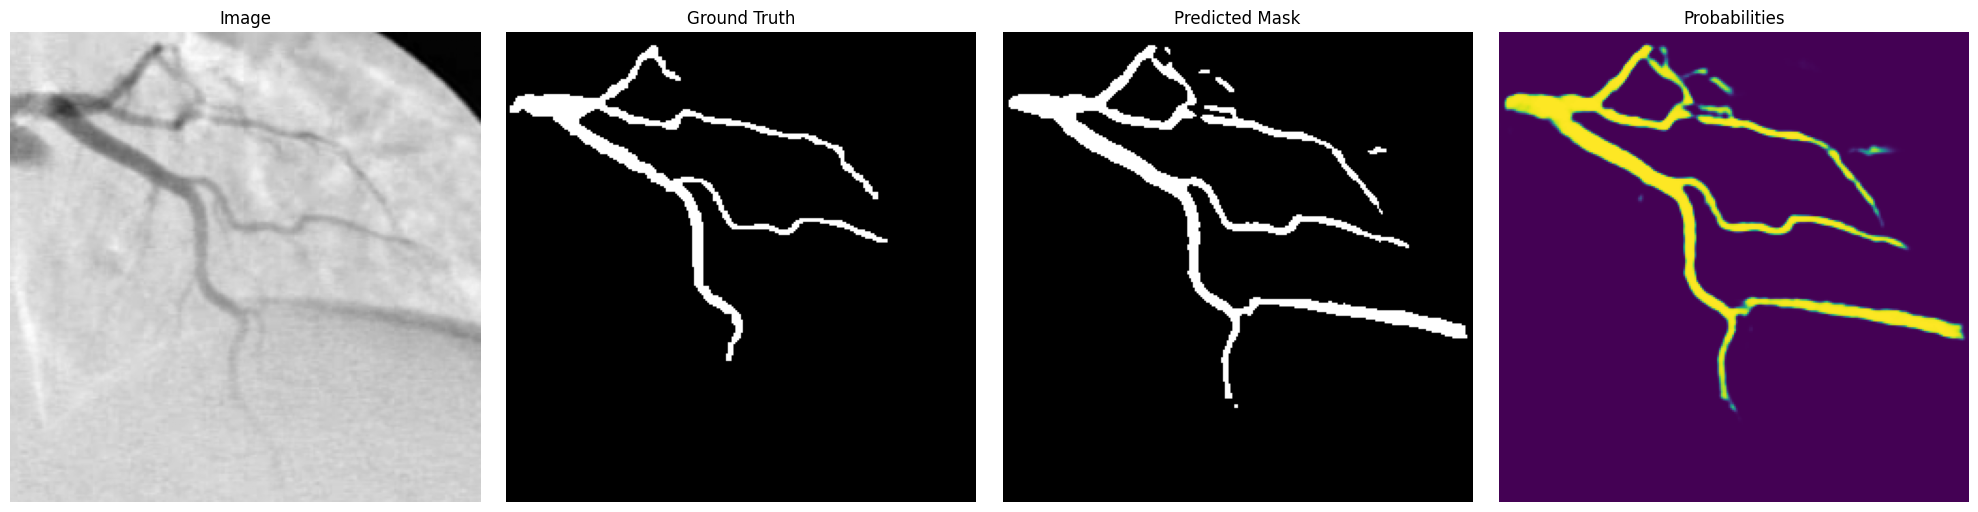

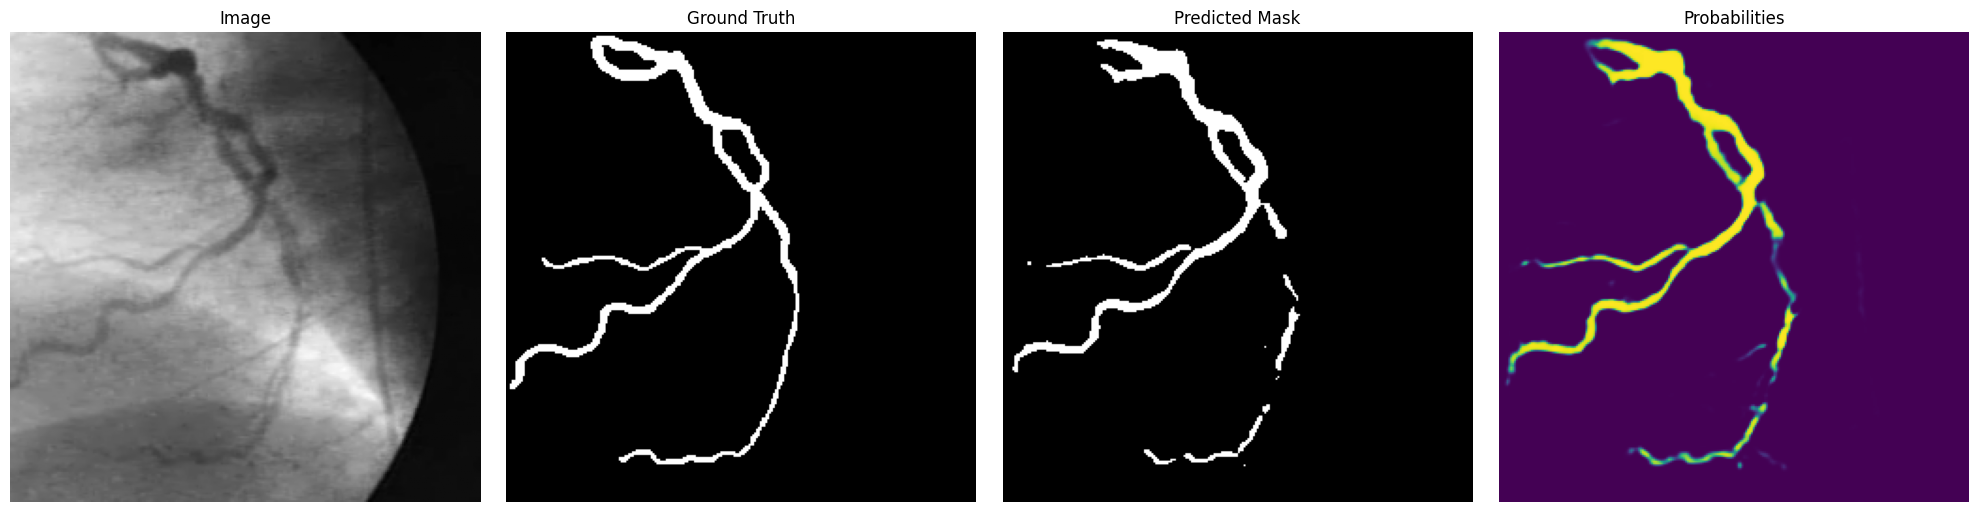

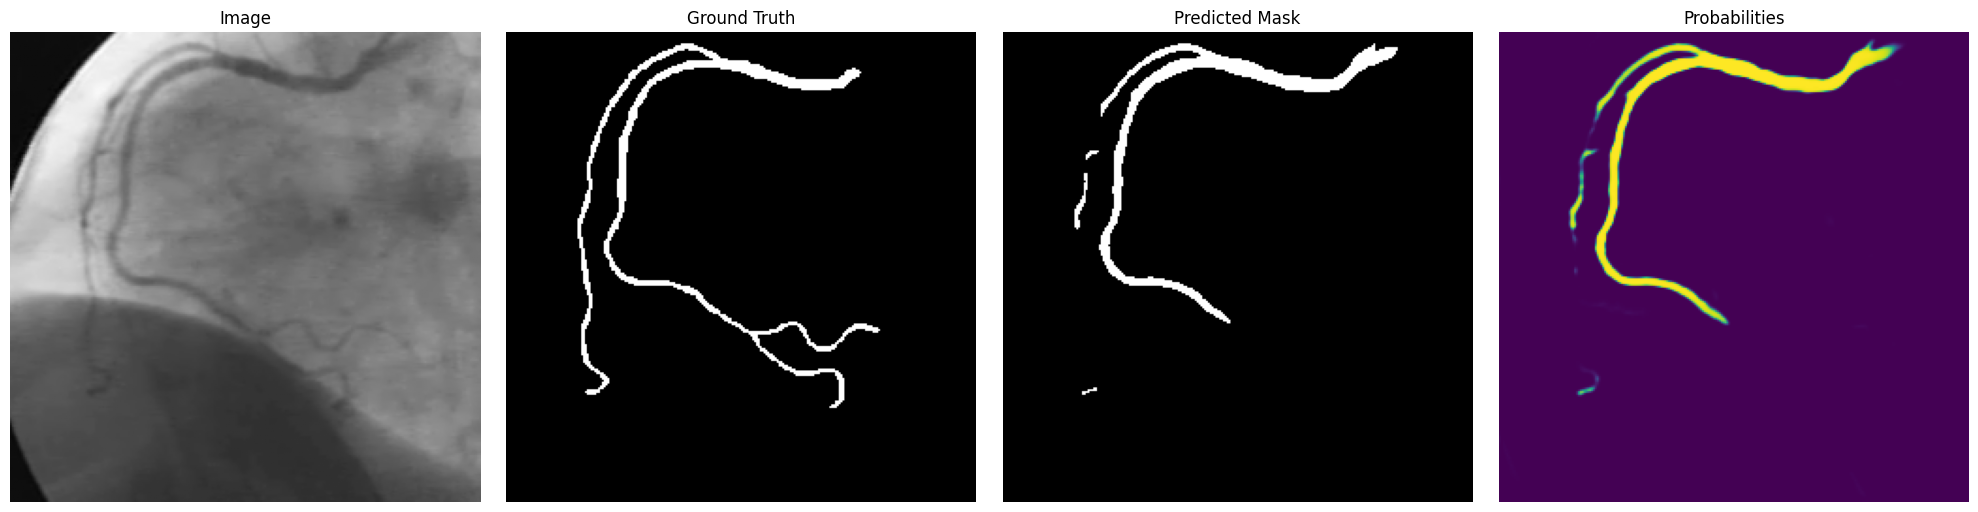

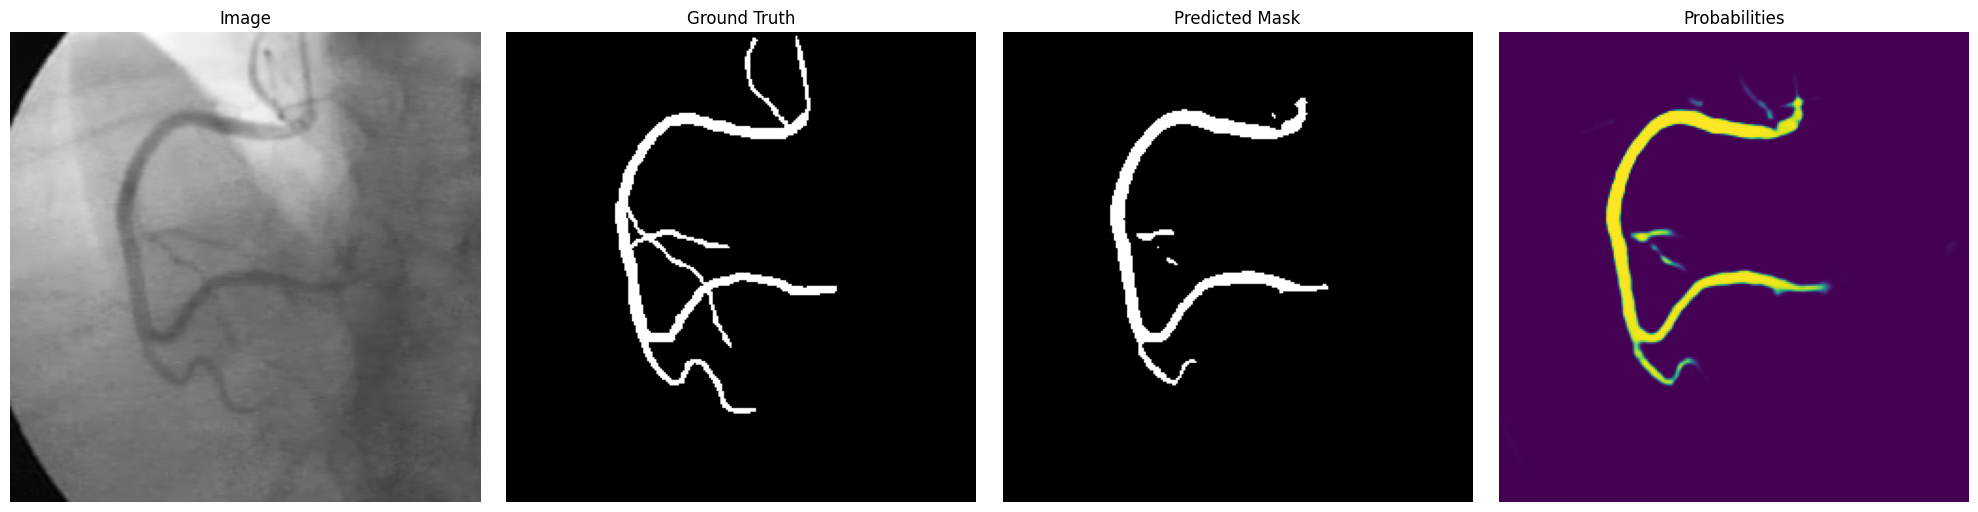

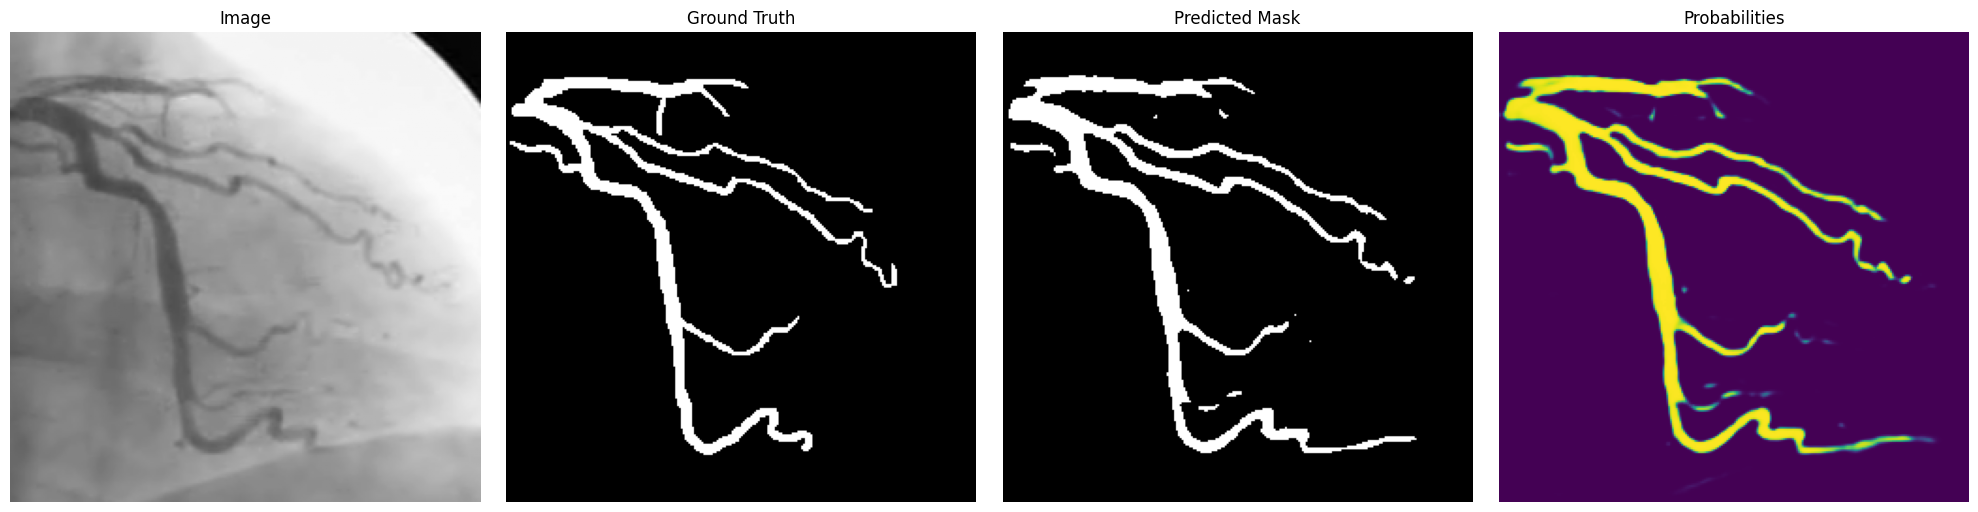

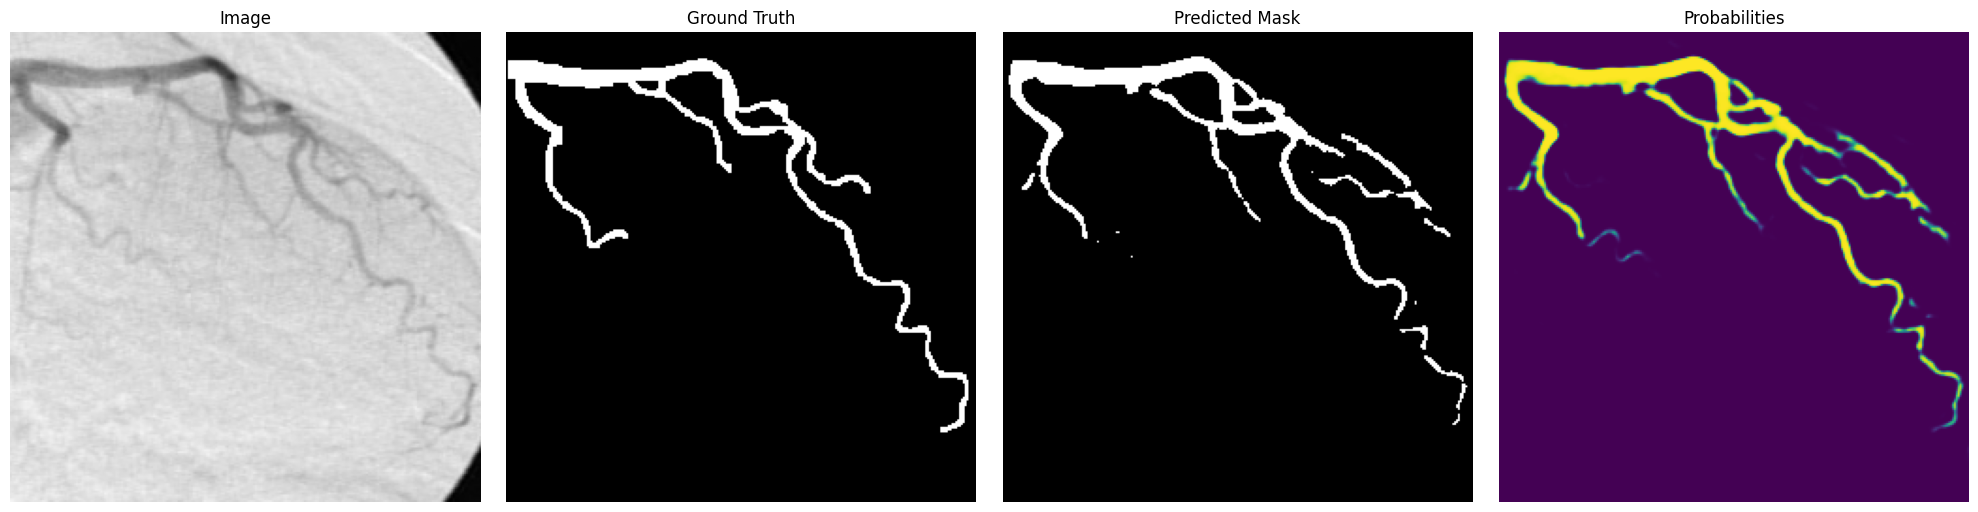

In [36]:
model.eval()

with torch.no_grad():
    val_loader_iter = iter(val_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(val_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for j in range(min(4, images.size(0))):
            show_image(
                images[j, 0].cpu().numpy(),
                masks[j, 0].cpu().numpy(),
                preds[j, 0].cpu().numpy(),
                probs[j, 0].cpu().numpy(),
                titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
                cmap=["gray", "gray", "gray", None],
            )

In [37]:
# val metrics

with torch.no_grad():
    val_loss, val_dice, val_iou = validate_one_epoch(
        model, val_loader, criterion, device
    )
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Dice Coefficient: {val_dice:.4f}")
    print(f"Validation IoU: {val_iou:.4f}")

Validation Loss: 0.2554
Validation Dice Coefficient: 0.7177
Validation IoU: 0.5613


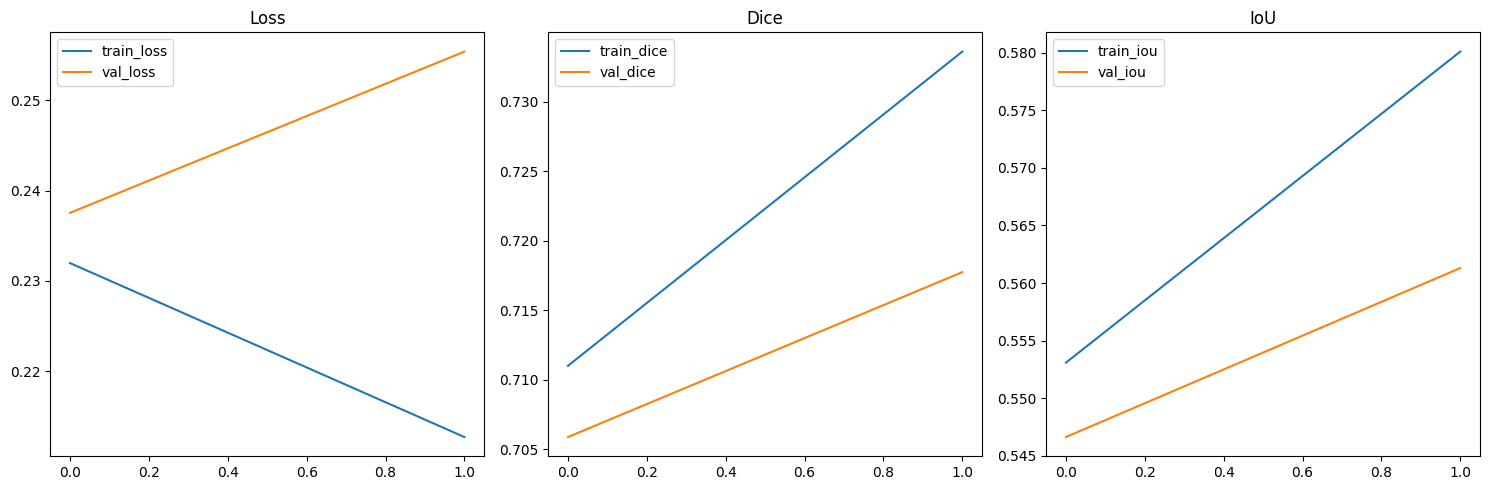

In [38]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
    (["train_dice", "val_dice"], "Dice"),
    (["train_iou", "val_iou"], "IoU"),
)

In [39]:
import os

if not os.path.exists("../models"):
    os.makedirs("../models")

torch.save(model.state_dict(), "../models/best_coronary_unet.pth")